# 02 - Preprocessing Pipeline (convert_sen12 + dataset)

This notebook walks through the preprocessing that turns one raw Sen12Landslides patch into the 42-channel input the U-Net consumes:

1. three event-aligned temporal windows (PRE / POST / LATE)
2. NDVI computed per window
3. DEM + slope terrain layers
4. validity channel (SCL-derived observation fraction)
5. z-score normalization with dataset-global statistics
6. label-trust weights for noisy polygon labels

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))
warnings.filterwarnings("ignore")

import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline

from paths import PATHS

In [2]:
tile = "chimanimani_s2_1000.h5"
with h5py.File(os.path.join(PATHS.TRAIN_IMG_DIR, tile), "r") as f:
    raw = np.array(f["img"])
print(f"Raw tile shape: {raw.shape}")
print("Layout: (N windows, H, W, 14 bands) with bands 0-9 spectral, 10 DEM, 11 slope, 12 validity, 13 NDVI")

Raw tile shape: (3, 128, 128, 14)
Layout: (N windows, H, W, 14 bands) with bands 0-9 spectral, 10 DEM, 11 slope, 12 validity, 13 NDVI


## 1. Temporal windows

Each window is the cloud-robust median of its acquisition frames (event-aligned per tile). Window 0 = PRE, 1 = POST, 2 = LATE (regrowth reference).

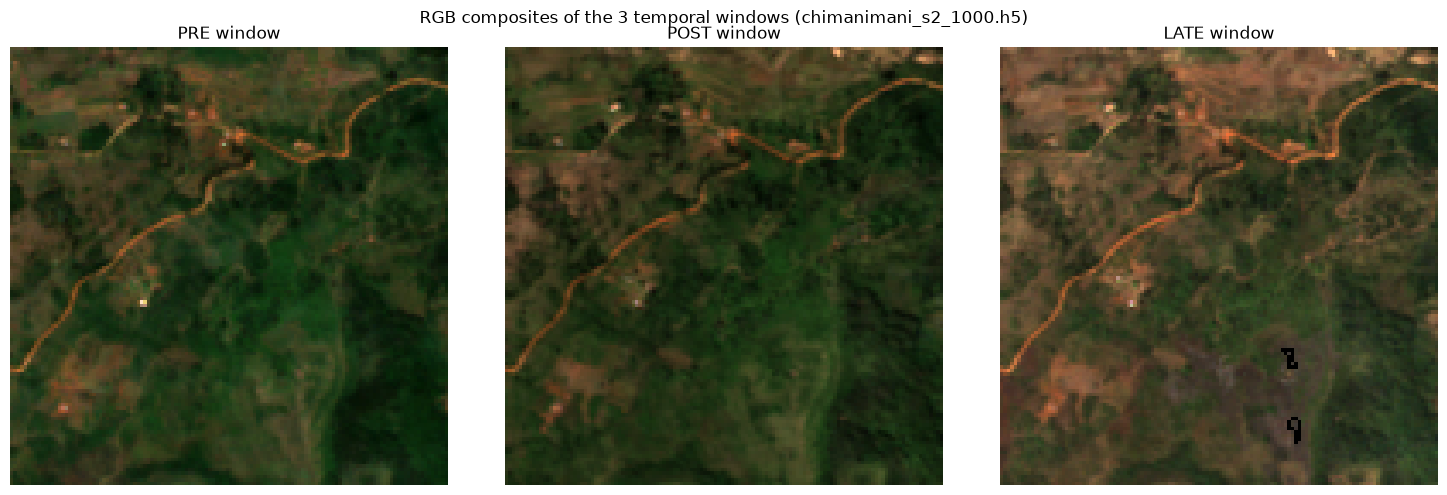

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = ["PRE window", "POST window", "LATE window"]
for i, (ax, name) in enumerate(zip(axes, names)):
    rgb = raw[i][..., [2, 1, 0]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    ax.imshow(rgb)
    ax.set_title(name)
    ax.axis("off")
fig.suptitle(f"RGB composites of the 3 temporal windows ({tile})")
plt.tight_layout()
plt.show()

## 2. NDVI, DEM, slope, validity

Physical layers the network sees: NDVI `(NIR-Red)/(NIR+Red)`, clipped DEM, slope in degrees, and the fraction of valid observations per pixel.

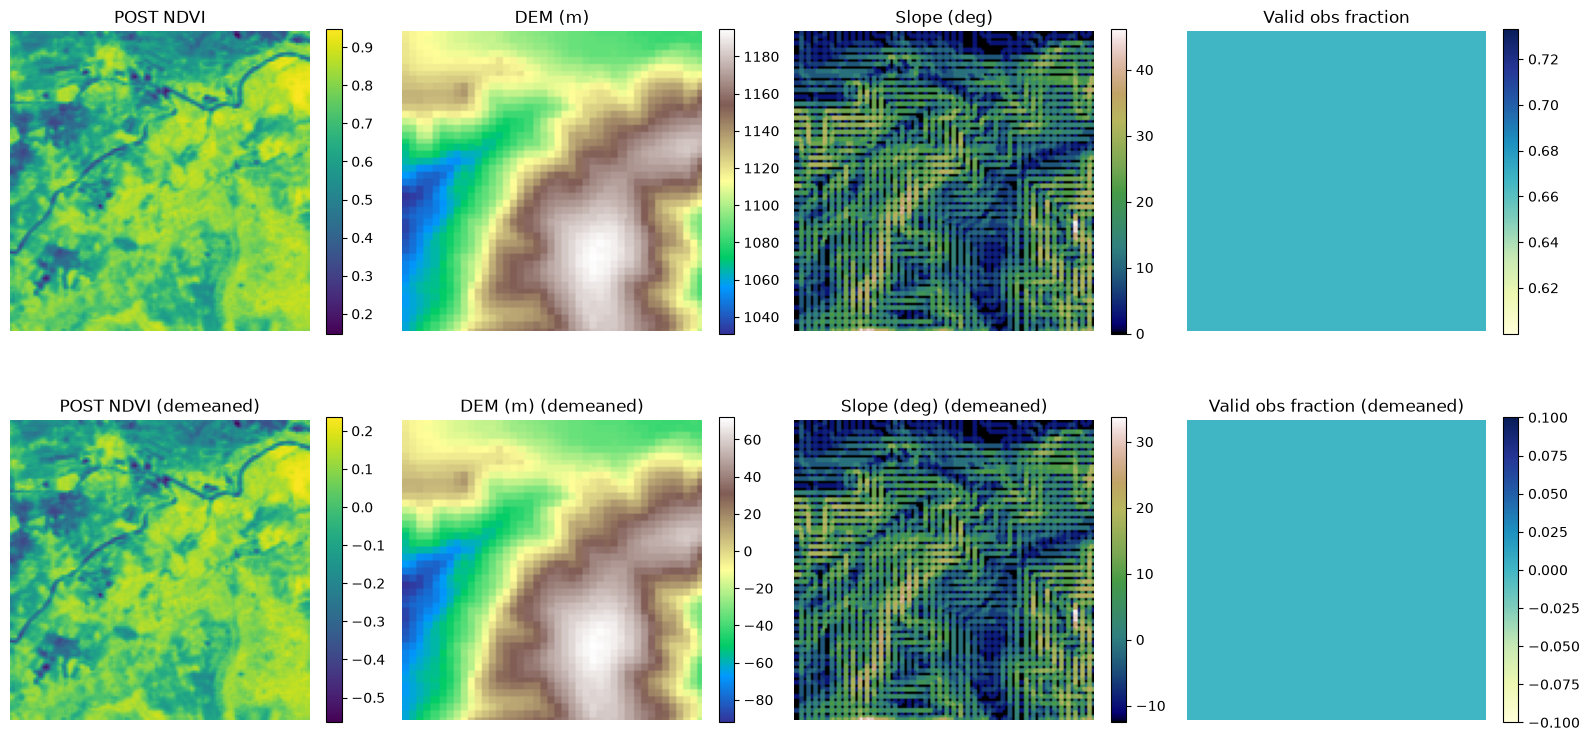

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
layers = [("POST NDVI", raw[1, :, :, 13], "viridis"),
          ("DEM (m)", raw[1, :, :, 10], "terrain"),
          ("Slope (deg)", raw[1, :, :, 11], "gist_earth"),
          ("Valid obs fraction", raw[1, :, :, 12], "YlGnBu")]
for col, (title, data, cmap) in enumerate(layers):
    im = axes[0, col].imshow(data, cmap=cmap)
    axes[0, col].set_title(title)
    plt.colorbar(im, ax=axes[0, col], fraction=0.046)

for col, (title, data, cmap) in enumerate(layers[:4]):
    im = axes[1, col].imshow(np.nan_to_num(data) - np.nanmean(np.nan_to_num(data)), cmap=cmap)
    axes[1, col].set_title(f"{title} (demeaned)")
    plt.colorbar(im, ax=axes[1, col], fraction=0.046)

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Z-score normalization

Dataset-global per-channel statistics keep cross-band physical relationships intact (per-image min-max would destroy them).

In [5]:
with np.load(PATHS.NORM_STATS) as d:
    mean, std = d["mean"], d["std"]
flat = raw.reshape(-1, 14)
z = (flat - mean) / np.where(std > 1e-6, std, 1.0)
print(f"Normalized pixel stats per channel (mean {z.mean(0).round(3)})")
print(f"Normalized std  per channel ({z.std(0).round(3)})")

Normalized pixel stats per channel (mean [-0.325 -0.315 -0.276 -0.202 -0.103 -0.095 -0.105 -0.059  0.159 -0.003
  0.704 -0.23  -0.135  0.425])
Normalized std  per channel ([0.136 0.176 0.286 0.24  0.407 0.439 0.447 0.422 0.488 0.578 0.059 0.6
 0.725 0.476])


## 4. Label-trust weights

The hand-drawn polygons over-cover real landslides (~40% of positive pixels look vegetated). The loss weights pixels by how much to trust them, and boosts the polygon boundary ring 1.5x.

Unique weight values: [0.65 1.  ]


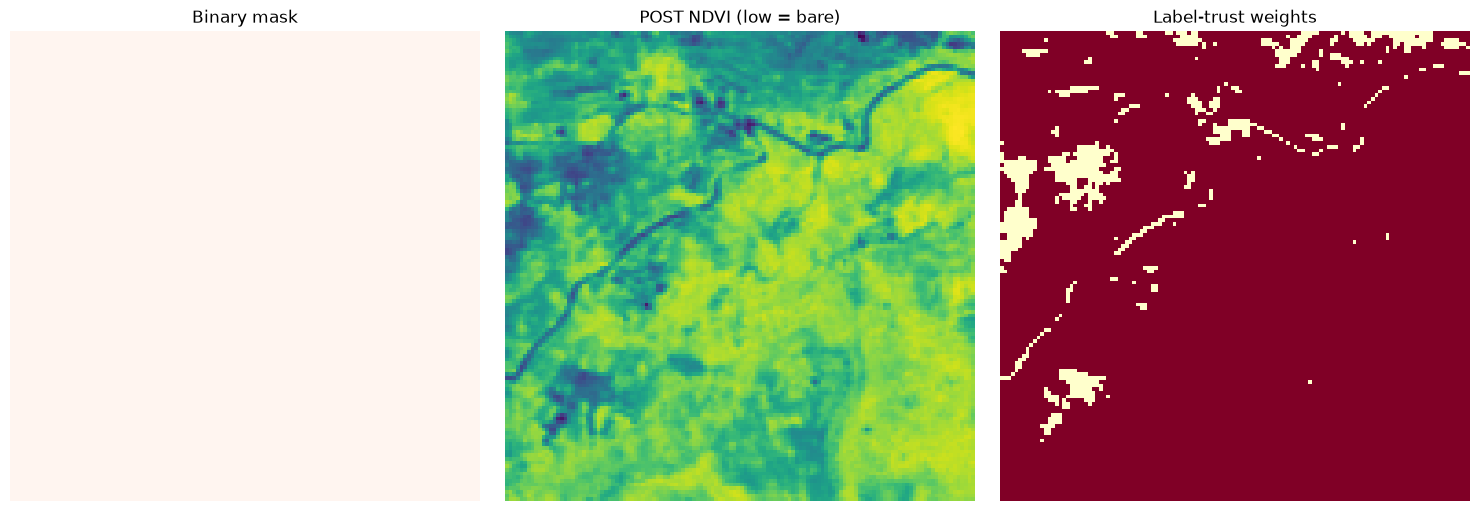

In [6]:
from dataset import compute_label_weights, POST_STACK
mask_path = os.path.join(PATHS.TRAIN_MASK_DIR, tile)
with h5py.File(mask_path, "r") as f:
    mask = np.array(f["mask"]) > 0.5
post_ndvi = raw[POST_STACK, :, :, 13]
weights = compute_label_weights(mask, post_ndvi)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mask, cmap="Reds"); axes[0].set_title("Binary mask")
axes[1].imshow(post_ndvi, cmap="viridis"); axes[1].set_title("POST NDVI (low = bare)")
axes[2].imshow(weights, cmap="YlOrRd"); axes[2].set_title("Label-trust weights")
for ax in axes:
    ax.axis("off")
print(f"Unique weight values: {np.unique(weights)}")
plt.tight_layout()
plt.show()

## 5. Final network input

The (3,128,128,14) stack is flattened channel-wise into (42,128,128) - `[PRE 0-13 | POST 14-27 | LATE 28-41]` - exactly what `CustomUNet` consumes.

In [7]:
from dataset import stack_temporal_stacks, normalize_standardized_image
normalized = normalize_standardized_image(raw, mean, std)
network_input = stack_temporal_stacks(normalized)
print(f"Network input shape: {network_input.shape}  (42, H, W)")
print("Channel 27 = POST NDVI (used by the NDVI gate), channel 13 = PRE NDVI")

Network input shape: (42, 128, 128)  (42, H, W)
Channel 27 = POST NDVI (used by the NDVI gate), channel 13 = PRE NDVI
